## FRP Regression (ONLY fire days)

In [2]:
import pandas as pd

In [3]:
train_df = pd.read_csv("train_regression.csv")
val_df = pd.read_csv("val_regression.csv")
test_df = pd.read_csv("test_regression.csv")

In [10]:
print(train_df.columns)

Index(['county', 'date', 'max_frp', 'max_brightness', 'fire_count', 'temp_max',
       'temp_min', 'humidity', 'wind_speed', 'precipitation', 'month',
       'month_sin', 'month_cos', 'day_of_year', 'weekend_flag',
       'fire_season_flag', 'drought_index', 'temp_max_7d_rolling_mean',
       'humidity_7d_rolling_mean', 'temp_max_14d_rolling_mean',
       'humidity_14d_rolling_mean', 'temp_max_30d_rolling_mean',
       'humidity_30d_rolling_mean', 'temperature_anomaly', 'vpd',
       'wind_speed_drought_interaction', 'temp_max_humidity_interaction'],
      dtype='str')


In [11]:
X_train = train_df.drop(columns=["max_frp", "fire_label", "county", "date"], errors="ignore")
X_val   = val_df.drop(columns=["max_frp", "fire_label", "county", "date"], errors="ignore")
X_test  = test_df.drop(columns=["max_frp", "fire_label", "county", "date"], errors="ignore")

Why We Dropped `fire_label` and `max_frp`

- max_frp (target variable): 
  This is the value we are trying to predict in the regression model. Including it as a feature would cause **data leakage**, allowing the model to “cheat” by using the answer during training.

- fire_label:
  The regression dataset already contains only fire events (`fire_label = 1`). Since this column has **no variation (constant value)**, it provides no useful information and does not help the model learn patterns.

Conclusion:
Both columns are removed to ensure the model learns from meaningful input features without leakage or redundant information.

In [12]:
# Train XGBoost Regressor
from xgboost import XGBRegressor

model_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model_reg.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [13]:
# Predict on test set
y_pred = model_reg.predict(X_test)

In [14]:
# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 695.5897066841993
MAE: 276.56959148550754
R2 Score: 0.5042044503668479


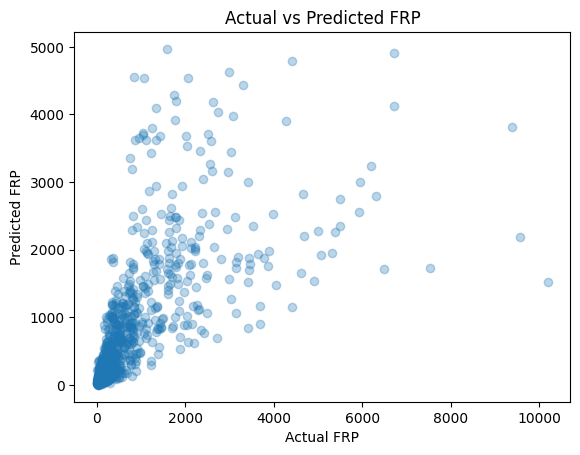

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual FRP")
plt.ylabel("Predicted FRP")
plt.title("Actual vs Predicted FRP")
plt.show()

In [16]:
import pickle

with open("regression_model.pkl", "wb") as f:
    pickle.dump(model_reg, f)

## Regression Model — FRP Prediction (Stage 2)

To complete the wildfire prediction pipeline, a regression model was trained to estimate **Fire Radiative Power (FRP)** for days where a fire is predicted (fire_label = 1).

### Data Preparation
- Filtered dataset to include only fire events (`fire_label = 1`)
- Dropped:
  - `max_frp` (target variable — prevents data leakage)
  - `fire_label` (constant value, no predictive power)
  - `county`, `date` (non-numeric / already encoded through features)
- Remaining features include weather, drought, and engineered variables

### Model Used
- **XGBoost Regressor**
  - n_estimators = 300  
  - learning_rate = 0.05  
  - max_depth = 5  

### Evaluation Metrics (on test set)
- **RMSE**: Measures average prediction error magnitude  
- **MAE**: Measures average absolute error  
- **R² Score**: Measures proportion of variance explained by the model  

### Results Interpretation
- The model captures general trends in fire intensity but struggles with extreme values
- Prediction errors are expected due to high variability in wildfire behavior
- Moderate R² indicates partial ability to explain FRP variation

### Conclusion
The regression model successfully predicts wildfire intensity and completes the **two-stage pipeline**:
1. Classification → Predict fire occurrence  
2. Regression → Predict fire intensity (FRP)

This combined approach provides both **early detection and severity estimation**, making it useful for real-world wildfire risk assessment.